# Introductory Data Analysis

Some questions we ask:
1. Does misorientation angle impact average thermal resistance ($R_B$ averaged across the GB) for coincident site lattice (CSL) GBs?

We just reproduce the plot from Heat Transport at Silicon Grain Boundaries (Isotta et al. 2024). 

2. How much variation in $R_B$ is present across the same grain boundary?

We look for normality of the noise. Remember that according to (Isotta et al. 2024), "We remark that each image corresponds to the average of three κ images of the same region, in order to reduce the error that stems from incoherent noise in the measurement," end of section 2.1.

3. Is the variance in $R_B$ across GBs meaningfully different based on properties of the GB?

We might consider the misorientation angle, roughness, nanotwinning, or angle from GB to sample vertical, as in (Isotta et al. 2024). We create a new dataset linking each region (A1-A11) to these features. These can be read off of `Si_area_CSL.png`. 

To get the sample vertical, I pasted the image into vector art software (Figma) and tried to match the line angle. I'd say it's accurate within plus or minus 1 degree. These are stored in `cleaned_si_data/area_properties.csv`.

Some GBs were "bent shaped". In this case, I took the angle of the line from the beginning of the red dotted line to the end, although this may not be a good idea. The "bent shaped" ones were A4, A11, and A3. We might consider splitting A3 in particular.

**For Guanying:**
1. Are the provided data points in the data you provided me also an average of three values?
2. Would you be able to check over the `cleaned_si_data/area_properties.csv` file and make sure I correctly specified the misorientation angle, roughness, nanotwinning, and angle from GB to sample vertical for each?
3. I observed very large outliars along the measurement boundary (see `raw_si_data/M31_A10/top_GB/M42result_RB_along_polyGB`). This can cause the estimate of the mean and variance to be affected. Based on your physical understanding, does this seem to be due to some physical defect in the property (at that point in space, there's some crystal impurity that has a very different $R_B$ value), or some sort of systematic measurement error (since this is FDTR, some momentary issue with the laser?)
4. Should we split A3 into left GB and right GB, similarly to A2?

In [176]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import shapiro, median_abs_deviation

## Question 1: Reproducing Plot from Heat Transport at Silicon Grain Boundaries (2024)
As the paper mentions in the abstract, "coincident site lattice boundaries exhibit uniform excess thermal resistance along the same boundary." Therefore, we expect $R_B$ not to change very much with CSL type.

![silicon_gb_csl_rb.png](figures/silicon_gb_csl_rb.png)

In [177]:
averaged_data = pd.read_csv("data/averaged_si_data/PolySi_GBangle.xlsx - Cleaned.csv")

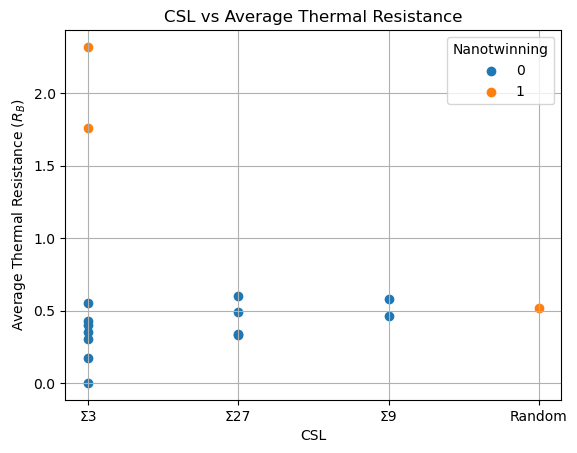

In [178]:
# plot CSL (categorical) vs Average Thermal Resistance (numerical) for each CSL category
csl_categories = sorted(averaged_data['CSL'].unique())
nanotwinning_values = averaged_data['Nanotwinning'].unique()
for nano in nanotwinning_values:
    subset = averaged_data[averaged_data['Nanotwinning'] == nano]
    plt.scatter(subset['CSL'], subset['Thermal Resistance'], label=nano)
plt.xlabel('CSL')
plt.ylabel(r'Average Thermal Resistance ($R_B$)')
plt.title('CSL vs Average Thermal Resistance')
plt.grid(True)
plt.legend(title="Nanotwinning")
plt.show()

Since data was not sent over for all A1-A11 (missing A1 and A6), and there are multiple grain boundaries included for A2, A10, A8, and A9, the plots slightly differ, but this is overall in agreement.

## Question 2: Quantifying Variation Across GBs

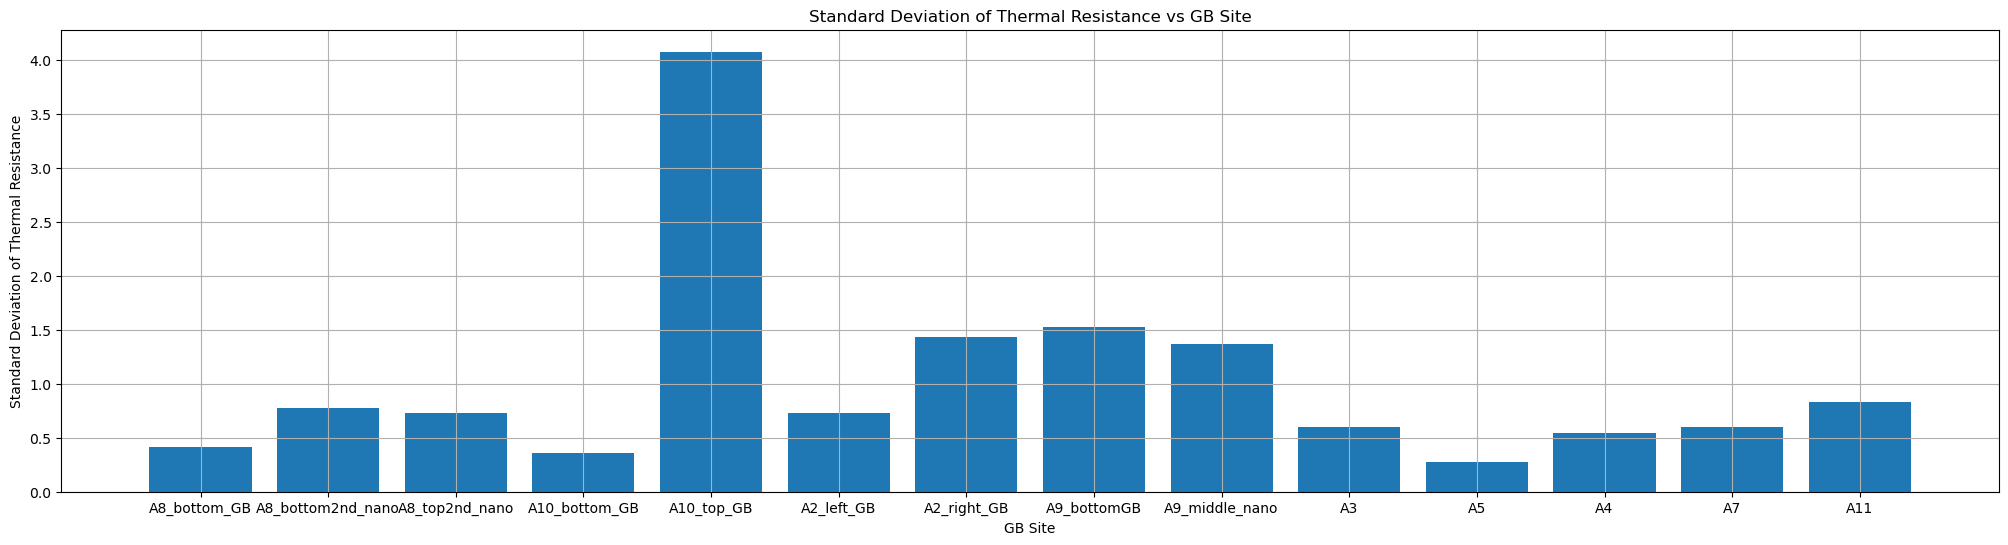

In [179]:
cleaned_data = pd.read_csv("data/cleaned_si_data/cleaned_si_data.csv", index_col=0)
# gb sites are current index
gb_sites = cleaned_data.index.unique()

# get std dev of thermal resistance for each gb site
std_devs = []
for gb in gb_sites:
    gb_data = cleaned_data[cleaned_data.index == gb]
    std_dev = gb_data['Thermal Resistance'].std()
    std_devs.append(std_dev)

# plot CSL vs std dev of thermal resistance
plt.figure(figsize=(25, 6))
plt.bar(gb_sites, std_devs)
plt.xlabel('GB Site')
plt.ylabel('Standard Deviation of Thermal Resistance')
plt.title('Standard Deviation of Thermal Resistance vs GB Site')
plt.grid(True)
plt.show()

In [180]:
# shapiro-wilk test for normality for each GB site
# alpha = 0.05, use Bonferroni correction
alpha = 0.05 / len(gb_sites)
normality_results = {}
for gb in gb_sites:
    gb_data = cleaned_data[cleaned_data.index == gb]
    # eliminate NaN values
    gb_data = gb_data[~gb_data['Thermal Resistance'].isna()]
    stat, p = shapiro(gb_data['Thermal Resistance'])
    normality_results[gb] = (stat, p, p > alpha)

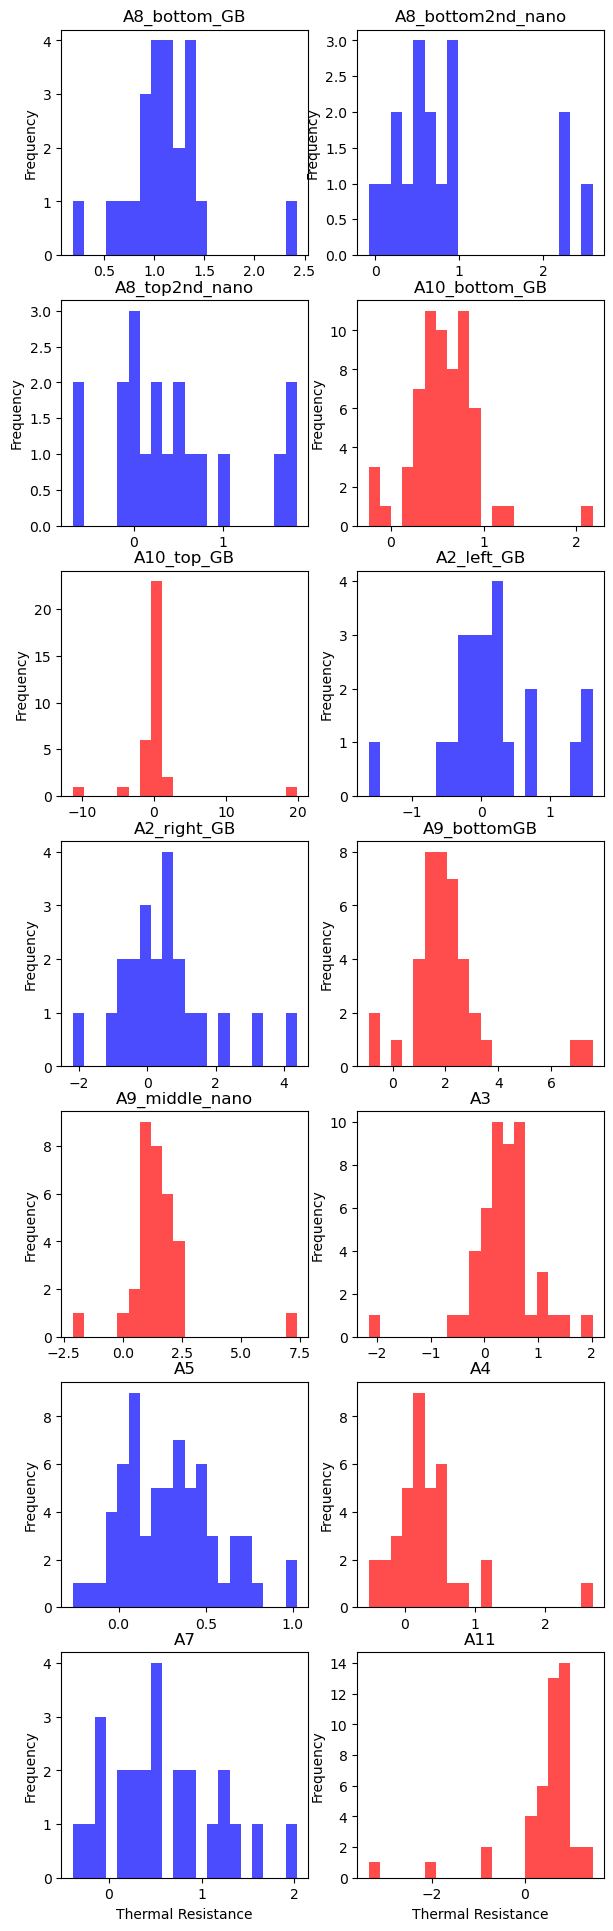

In [181]:
# plot histogram of Thermal Resistance values for each GB site
fig, axes = plt.subplots(len(gb_sites) // 2, 2, figsize=(7, 24))
for i, gb in enumerate(gb_sites):
    gb_data = cleaned_data[cleaned_data.index == gb]
    normality = normality_results[gb][2]
    # two columns
    ax = axes[i // 2, i % 2]
    ax.hist(gb_data['Thermal Resistance'], bins=20, alpha=0.7, color='blue' if normality else 'red')
    ax.set_title(f'{gb}')
    ax.set_ylabel('Frequency')

# set xlabel for bottom plots
for ax in axes[-1, :]:
    ax.set_xlabel('Thermal Resistance')
plt.show()

It seems like A10, A9, A5, and A4 have distributions that seem non-normal. This mostly seems to be caused by extreme outliars.

To deal with the outliars, we may consider using robust statistics (median instead of mean, median absolute deviation instead of standard deviation).

We now plot the MAD instead of the standard deviation. This results in significantly lower estimates of the "variation" within a single GB.

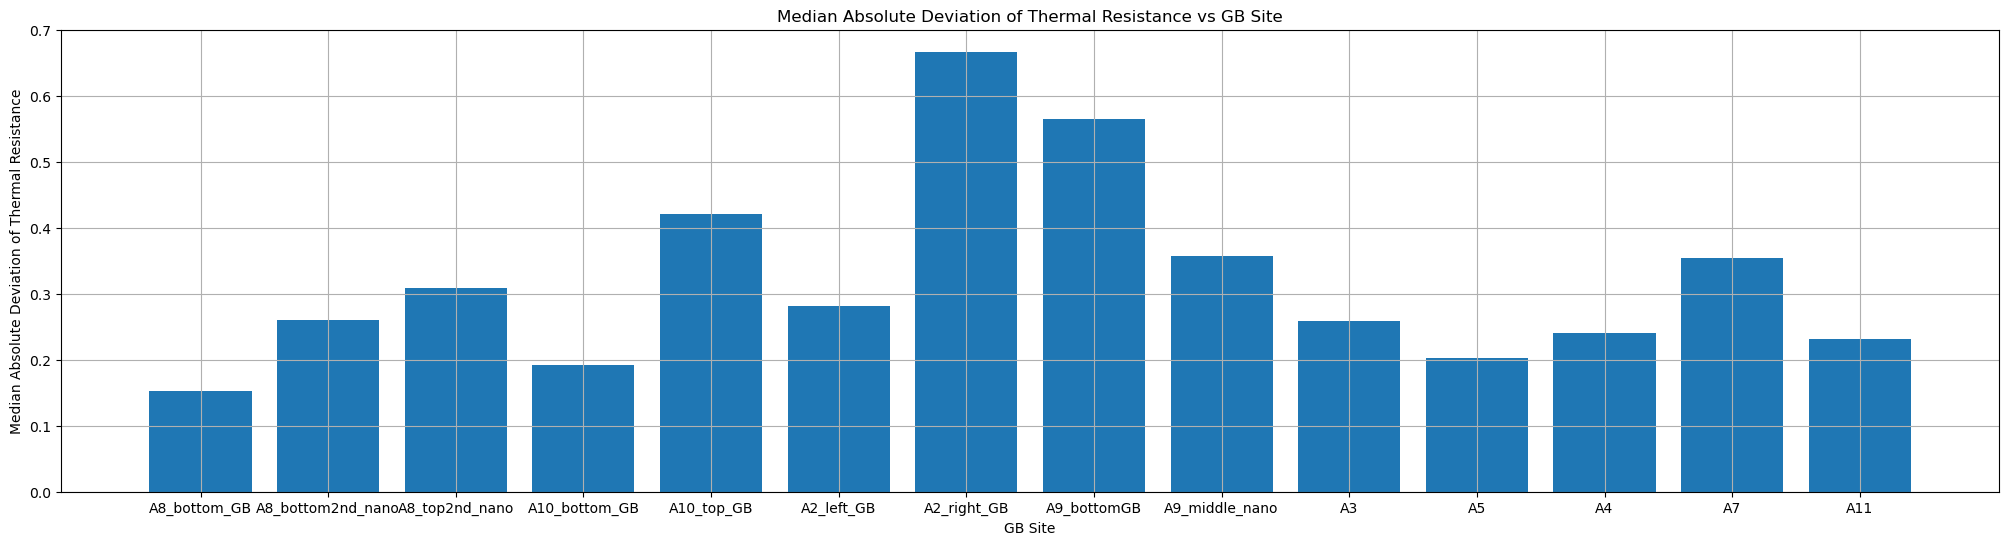

In [182]:
cleaned_data = pd.read_csv("data/cleaned_si_data/cleaned_si_data.csv", index_col=0)
# gb sites are current index
gb_sites = cleaned_data.index.unique()

# get median absolute deviation of thermal resistance for each gb site
mads = []
for gb in gb_sites:
    gb_data = cleaned_data[cleaned_data.index == gb]
    # get median absolute deviation
    mad = median_abs_deviation(gb_data['Thermal Resistance'], nan_policy='omit')
    mads.append(mad)

# plot CSL vs median absolute deviation of thermal resistance
plt.figure(figsize=(25, 6))
plt.bar(gb_sites, mads)
plt.xlabel('GB Site')
plt.ylabel('Median Absolute Deviation of Thermal Resistance')
plt.title('Median Absolute Deviation of Thermal Resistance vs GB Site')
plt.grid(True)
plt.show()

## Question 3: Properties of GBs affecting Variance of $R_B$ across it?

We plot CSL misorientation angle, nanotwinning, and angle to vertical vs. variance of $R_B$ across the GB.

In [183]:
area_properties = pd.read_csv("data/cleaned_si_data/area_properties.csv", index_col=0)
gb_sites = area_properties.index.unique()
std_devs = dict(zip(gb_sites, std_devs))
mads = dict(zip(gb_sites, mads))

### Misorientation Angle

We can't tell much since there are only three Σ27 GBs and a single Σ9 GB. **We should collect more data for these CSLs**.

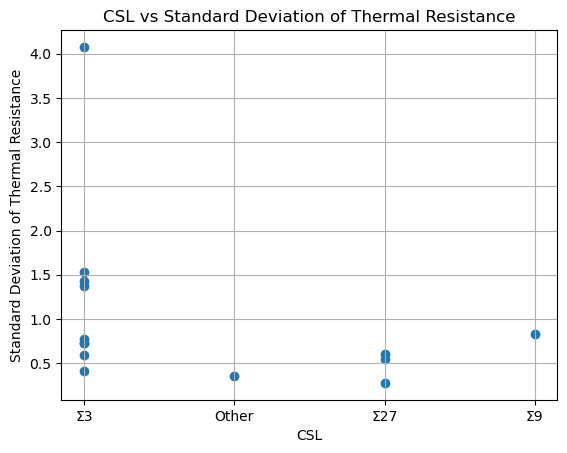

In [184]:
plt.scatter(area_properties['CSL'], [std_devs[gb] for gb in gb_sites])
plt.xlabel('CSL')
plt.ylabel('Standard Deviation of Thermal Resistance')
plt.title('CSL vs Standard Deviation of Thermal Resistance')
plt.grid(True)
plt.show()

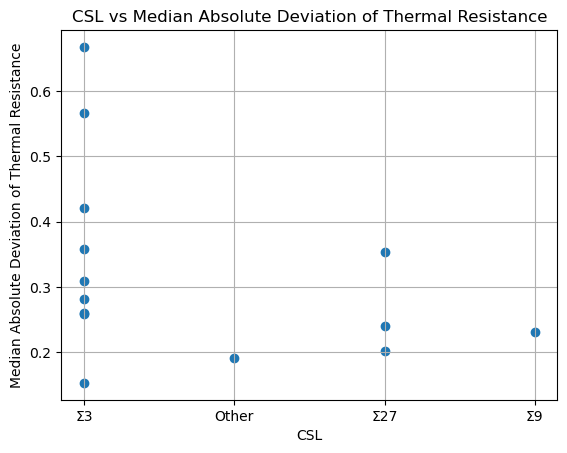

In [185]:
plt.scatter(area_properties['CSL'], [mads[gb] for gb in gb_sites])
plt.xlabel('CSL')
plt.ylabel('Median Absolute Deviation of Thermal Resistance')
plt.title('CSL vs Median Absolute Deviation of Thermal Resistance')
plt.grid(True)
plt.show()

### Nanotwinning

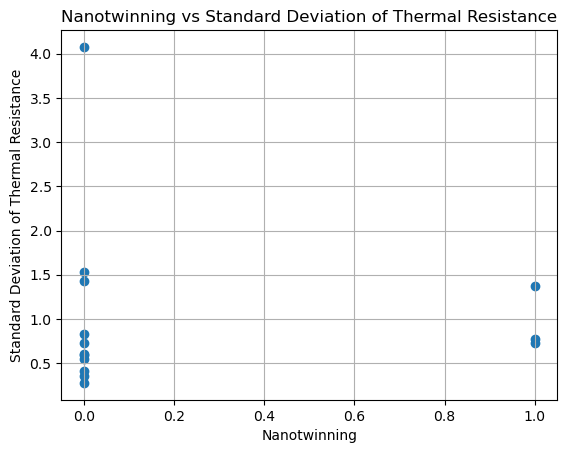

In [186]:
plt.scatter(area_properties['Nanotwinning'], [std_devs[gb] for gb in gb_sites])
plt.xlabel('Nanotwinning')
plt.ylabel('Standard Deviation of Thermal Resistance')
plt.title('Nanotwinning vs Standard Deviation of Thermal Resistance')
plt.grid(True)
plt.show()

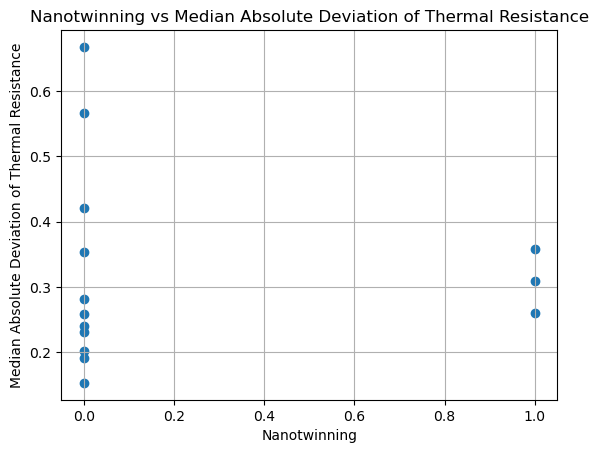

In [187]:
plt.scatter(area_properties['Nanotwinning'], [mads[gb] for gb in gb_sites])
plt.xlabel('Nanotwinning')
plt.ylabel('Median Absolute Deviation of Thermal Resistance')
plt.title('Nanotwinning vs Median Absolute Deviation of Thermal Resistance')
plt.grid(True)
plt.show()

### Angle to Vertical

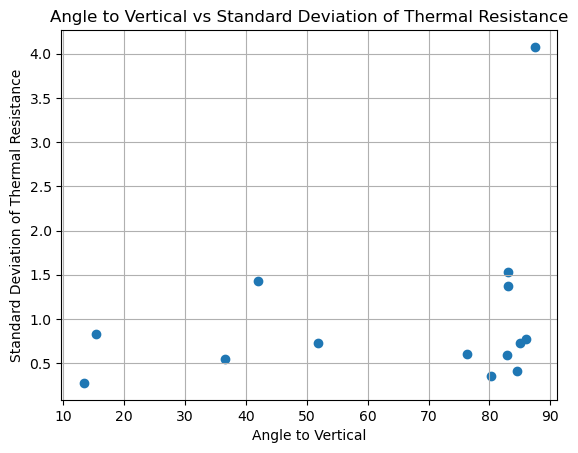

In [188]:
plt.scatter(area_properties['AngleToVertical'], [std_devs[gb] for gb in gb_sites])
plt.xlabel('Angle to Vertical')
plt.ylabel('Standard Deviation of Thermal Resistance')
plt.title('Angle to Vertical vs Standard Deviation of Thermal Resistance')
plt.grid(True)
plt.show()

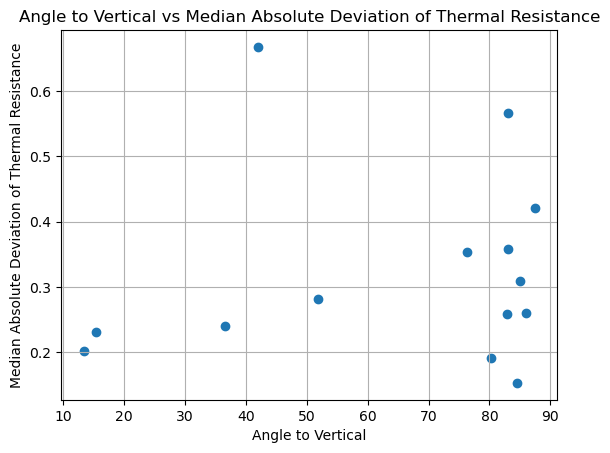

In [189]:
plt.scatter(area_properties['AngleToVertical'], [mads[gb] for gb in gb_sites])
plt.xlabel('Angle to Vertical')
plt.ylabel('Median Absolute Deviation of Thermal Resistance')
plt.title('Angle to Vertical vs Median Absolute Deviation of Thermal Resistance')
plt.grid(True)
plt.show()

I don't see anything particularly suggestive in these plots, although more data would definitely help!